Train shape : (2190325, 147)
Test  shape : (938711, 147)
불량률 Train : 0.51%
결측 70%+ 제거 후 Train shape : (2190325, 132)

[언더샘플링 후]
불량 : 11,268건
우량 : 112,680건
불량률 : 9.09%

IV 분석 대상 변수 수 : 131개

WoE·IV 계산 중... (수 분 소요)
[INFO] creating woe binning ...
Binning on 123948 rows and 123 columns in 00:01:04
완료

전체 변수 IV 계산 완료 : 122개

[IV 상위 30개]
 variable        iv
D10220000 13.226702
D10232000 10.251298
D1013A000  8.481194
D10110000  7.823899
D10133000  5.457518
D10142D0T  4.780708
C1L120170  3.079074
C1L120082  3.055383
C1M2B4W03  2.861452
C1L120032  2.603639
D10142D0N  2.477453
C1L120017  2.474960
C1L120169  2.397460
C1L120084  2.377340
C1M2B5W03  1.555420
C1L120251  1.544939
C1L120179  1.533509
C1L120242  1.513204
C1L120292  1.502635
C1L120237  1.385490
D1013A00T  1.263485
L102100CP  1.132027
L1021009P  1.112601
L10216000  1.101386
L1021006P  1.087806
L1021003P  1.073076
L1021001P  1.062248
L10220000  1.054545
L10210000  1.051720
L10173000  1.018465

IV >= 0.01 선별 변수 : 72개
IV <  0.01 제외 변수 : 5

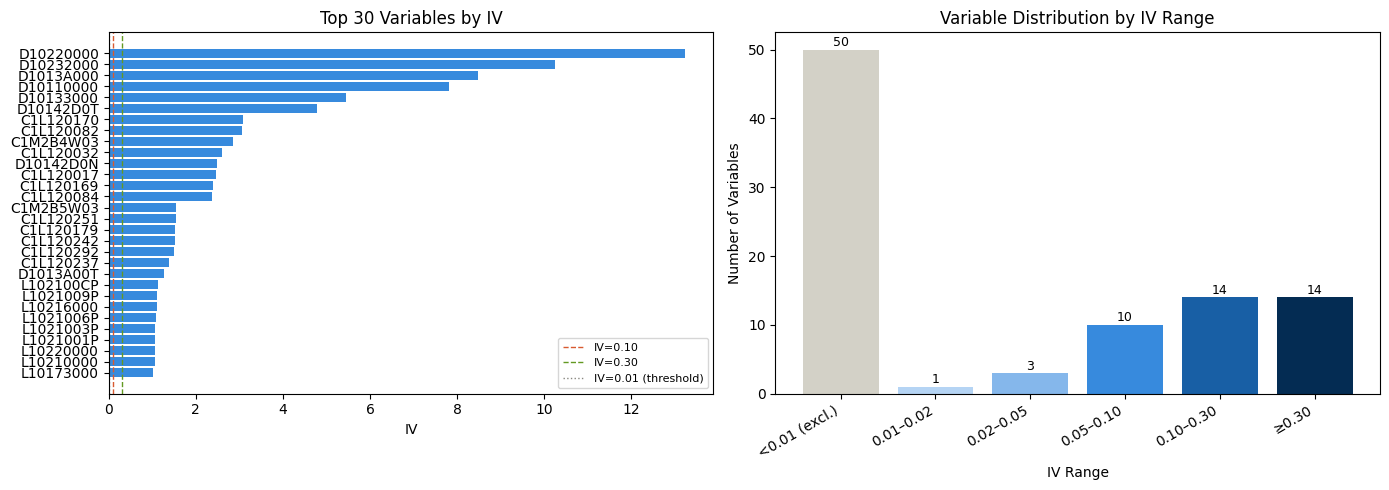


저장 완료:
  outputs/tables/02_iv_all.csv       (전체 IV)
  outputs/tables/02_iv_selected.csv  (IV>=0.01 선별)
  data/aihub_raw/02_woe_bins.pkl     (WoE bins → 03번 사용)

  IV >= 0.01 선별 변수 : 72개
  보고서 목표          : 394개
  차이                 : -322개

→ 02_iv_selected.csv 확인 후 03번 노트북으로 진행


In [4]:
# ============================================================
# 02_iv_analysis_variable_selection
# 단변량 IV 분석 및 변수 선별
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 데이터 로드
train = pd.read_csv('data/aihub_raw/01_train.csv', low_memory=False)
test  = pd.read_csv('data/aihub_raw/01_test.csv',  low_memory=False)

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"불량률 Train : {train['Y'].mean()*100:.2f}%")

# %% [3] 결측률 70% 초과 변수 제거
DROP_HIGH_MISSING = [
    'D10147000', 'D10155000',              # 연체 날짜 (연체없으면 결측)
    'AL0C00001', 'AL0C00002', 'AL0C00003', # 차량 종류·크기·수입여부
    'AL0C00004', 'AL0C00005',              # 차량 신중고·가격
    'C1L120001', 'C1L120012', 'C1L120024', # 카드한도 (결측 70%+)
    'C1L120049', 'C1L120171', 'C1L120196', # 카드한도 (결측 70%+)
    'C1L120270', 'C1L120272',              # 카드한도 (결측 70%+)
]

# 실제로 컬럼이 존재하는 것만 제거
drop_exist = [c for c in DROP_HIGH_MISSING if c in train.columns]
train.drop(columns=drop_exist, inplace=True)
test.drop(columns=drop_exist,  inplace=True)
print(f"결측 70%+ 제거 후 Train shape : {train.shape}")

# %% [4] 불량률 불균형 처리 — 언더샘플링
# 불량률 0.51% → IV 분석 전 샘플 균형 조정
# 불량:우량 = 1:10 비율로 언더샘플링 (분석용 서브셋)

bad  = train[train['Y'] == 1]
good = train[train['Y'] == 0]

# 불량 건수의 10배 우량 샘플링
good_sample = good.sample(n=min(len(bad)*10, len(good)), random_state=42)
train_balanced = pd.concat([bad, good_sample]).sample(frac=1, random_state=42)

print(f"\n[언더샘플링 후]")
print(f"불량 : {train_balanced['Y'].sum():,}건")
print(f"우량 : {(train_balanced['Y']==0).sum():,}건")
print(f"불량률 : {train_balanced['Y'].mean()*100:.2f}%")

# %% [5] IV 계산 대상 컬럼 선정
# GENDER, AGE_BAND 는 층화 변수로 별도 처리
iv_target_cols = [c for c in train_balanced.columns
                  if c not in ['Y', 'GENDER', 'AGE_BAND']]

print(f"\nIV 분석 대상 변수 수 : {len(iv_target_cols)}개")

# %% [6] WoE · IV 계산 (scorecardpy)
# scorecardpy 는 Y 컬럼명을 직접 지정
# bin 자동 분할 (최대 5구간, 단조성 체크)

print("\nWoE·IV 계산 중... (수 분 소요)")
bins = sc.woebin(
    train_balanced[iv_target_cols + ['Y']],
    y='Y',
    positive='bad|1',
    stop_limit=0.1,       # 분할 중단 기준
    count_distr_limit=0.05
)
print("완료")

# %% [7] 변수별 IV 추출 및 정렬
iv_list = []
for col, bin_df in bins.items():
    iv_val = bin_df['total_iv'].iloc[0]
    iv_list.append({'variable': col, 'iv': round(iv_val, 6)})

iv_df = pd.DataFrame(iv_list).sort_values('iv', ascending=False).reset_index(drop=True)

print(f"\n전체 변수 IV 계산 완료 : {len(iv_df)}개")
print("\n[IV 상위 30개]")
print(iv_df.head(30).to_string(index=False))

# %% [8] IV 기준 변수 선별
# 논문 기준: IV >= 0.01 선별 (보고서 394개 재현 목표)

IV_THRESHOLD = 0.01
selected = iv_df[iv_df['iv'] >= IV_THRESHOLD].copy()
excluded = iv_df[iv_df['iv'] <  IV_THRESHOLD].copy()

print(f"\n{'='*45}")
print(f"IV >= {IV_THRESHOLD} 선별 변수 : {len(selected)}개")
print(f"IV <  {IV_THRESHOLD} 제외 변수 : {len(excluded)}개")
print(f"{'='*45}")

# IV 구간별 분포
bins_iv = [0, 0.01, 0.02, 0.05, 0.1, 0.3, 1.0]
labels  = ['<0.01(제외)', '0.01-0.02', '0.02-0.05',
           '0.05-0.10', '0.10-0.30', '>=0.30']
iv_df['iv_band'] = pd.cut(iv_df['iv'], bins=bins_iv, labels=labels, right=False)
print("\n[IV 구간별 변수 수]")
print(iv_df['iv_band'].value_counts().sort_index().to_string())

# %% [9] 보고서 공통변수 11개 IV 확인
# 연구기획서 Table 4.2 기준 변수 (개인CB 포함 항목)
REPORT_VARS = {
    'NI_PD0801_000': 'U81201010',  # 자산소득평가지수 → 총자산평가금액
    'NI_IE0400008' : None,          # 최종소득등급 (개인CB 파일 미포함 가능)
    'WB_DFRS_DPST_BAL': None,       # 거치식예금잔액 (05번 파일)
    'WB_SCDL_BAL'  : None,          # 담보대출잔액 (05번 파일)
}

print("\n[연구기획서 공통변수 中 개인CB 매핑 확인]")
for report_nm, col in REPORT_VARS.items():
    if col and col in iv_df['variable'].values:
        iv_val = iv_df[iv_df['variable']==col]['iv'].values[0]
        print(f"  {report_nm} ({col}) : IV = {iv_val:.4f}")
    elif col:
        print(f"  {report_nm} ({col}) : 결측 70%+ 제거로 분석 제외")
    else:
        print(f"  {report_nm} : 타 파일 변수 (개인CB 미포함)")

# %% [10] IV 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 상위 30개 변수 IV 바차트
top30 = iv_df.head(30)
axes[0].barh(top30['variable'][::-1], top30['iv'][::-1], color='#378ADD')
axes[0].axvline(x=0.1,  color='#D85A30', linestyle='--', linewidth=1, label='IV=0.10')
axes[0].axvline(x=0.3,  color='#639922', linestyle='--', linewidth=1, label='IV=0.30')
axes[0].axvline(x=0.01, color='#888780', linestyle=':',  linewidth=1, label='IV=0.01 (threshold)')
axes[0].set_xlabel('IV')
axes[0].set_title('Top 30 Variables by IV')
axes[0].legend(fontsize=8)

# 오른쪽: IV 구간별 분포
band_counts = iv_df['iv_band'].value_counts().sort_index()
iv_band_labels_en = ['<0.01 (excl.)', '0.01–0.02', '0.02–0.05',
                     '0.05–0.10', '0.10–0.30', '≥0.30']
colors = ['#D3D1C7', '#B5D4F4', '#85B7EB', '#378ADD', '#185FA5', '#042C53']
axes[1].bar(range(len(band_counts)), band_counts.values, color=colors[:len(band_counts)])
axes[1].set_xticks(range(len(band_counts)))
axes[1].set_xticklabels(iv_band_labels_en[:len(band_counts)], rotation=30, ha='right')
axes[1].set_xlabel('IV Range')
axes[1].set_ylabel('Number of Variables')
axes[1].set_title('Variable Distribution by IV Range')
for i, v in enumerate(band_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/02_iv_distribution.png', dpi=150)
plt.show()

# %% [11] 선별 변수 저장
iv_df.to_csv('outputs/tables/02_iv_all.csv', index=False, encoding='utf-8-sig')
selected.to_csv('outputs/tables/02_iv_selected.csv', index=False, encoding='utf-8-sig')

# WoE bins 저장 (03번 노트북에서 사용)
import pickle
with open('data/aihub_raw/02_woe_bins.pkl', 'wb') as f:
    pickle.dump(bins, f)

print("\n저장 완료:")
print("  outputs/tables/02_iv_all.csv       (전체 IV)")
print("  outputs/tables/02_iv_selected.csv  (IV>=0.01 선별)")
print("  data/aihub_raw/02_woe_bins.pkl     (WoE bins → 03번 사용)")

# %% [12] 최종 요약
print(f"\n{'='*45}")
print(f"  IV >= 0.01 선별 변수 : {len(selected)}개")
print(f"  보고서 목표          : 394개")
print(f"  차이                 : {len(selected) - 394:+}개")
print(f"{'='*45}")
print("\n→ 02_iv_selected.csv 확인 후 03번 노트북으로 진행")

In [5]:
# ============================================================
# 02b — IV 진단 셀 (02번 노트북 이어서 실행)
# 72개 선별 결과 검증 및 논문 기재용 수치 확인
# ============================================================

# %% [D1] 연구기획서 11개 공통변수 매핑 확인
# 개인CB 파일에서 대응 가능한 변수만 체크
COMMON_VARS_REPORT = {
    'NI_PD0801_000 (자산소득평가지수)' : 'U81201010',
    'NI_IE0400008  (최종소득등급)'     : None,        # 개인CB 미포함
    'WB_DFRS_DPST_BAL (거치식예금잔액)': None,        # 05번 파일
    'WB_SCDL_BAL (담보대출잔액)'       : None,        # 05번 파일
    'comm_sns_22_1 (SNS 커뮤 관심도)'  : None,        # 11번 파일
    'shc_236_222Q (전자상거래 이용금액)': None,        # 11번 파일
    'shop_social_22_2 (소셜커머스)'    : None,        # 11번 파일
    'shop_jikgu_22_2 (해외직구)'       : None,        # 11번 파일
    'KT_SERVICE_13 (페이스북 사용일수)' : None,        # 11번 파일
    'KT_SERVICE_11 (인스타그램 사용일수)': None,       # 11번 파일
    'KT_SERVICE_8 (네이버쇼핑 사용일수)': None,        # 11번 파일
}

print("=" * 60)
print("연구기획서 11개 공통변수 — 개인CB 파일 내 매핑 현황")
print("=" * 60)
for nm, col in COMMON_VARS_REPORT.items():
    if col is None:
        print(f"  {nm:<45} : 타 파일 변수")
    elif col in iv_df['variable'].values:
        iv_val = iv_df[iv_df['variable'] == col]['iv'].values[0]
        flag = '✓ 선별' if iv_val >= 0.01 else '✗ IV 미달'
        print(f"  {nm:<45} : IV={iv_val:.4f}  [{flag}]")
    else:
        print(f"  {nm:<45} : 결측 70%+ 제거로 분석 제외")

# %% [D2] 72개 선별 변수 그룹별 분포
selected = iv_df[iv_df['iv'] >= 0.01].copy()

groups = {
    'Card (C)'         : [c for c in selected['variable'] if c.startswith('C')],
    'Loan (L)'         : [c for c in selected['variable'] if c.startswith('L')],
    'Asset index (U)'  : [c for c in selected['variable'] if c.startswith('U')],
    'Delinquency (D)'  : [c for c in selected['variable'] if c.startswith('D')],
    'Alternative (A)'  : [c for c in selected['variable'] if c.startswith('A')],
}

print("\n" + "=" * 40)
print("Selected Variables by Group (IV >= 0.01)")
print("=" * 40)
for g, cols in groups.items():
    print(f"  {g:<20} : {len(cols):>3}개")
print(f"  {'Total':<20} : {len(selected):>3}개")

# %% [D3] IV 분포 비교 — 보고서 vs 현재
print("\n" + "=" * 60)
print("IV 분포 비교")
print("=" * 60)
print(f"  {'항목':<35} {'보고서':>8} {'현재':>8}")
print("-" * 60)
print(f"  {'분석 파일 수':<35} {'10개':>8} {'1개':>8}")
print(f"  {'후보 변수 수':<35} {'1,310개':>8} {len(iv_df):>7}개")
print(f"  {'IV >= 0.01 선별 수':<35} {'394개':>8} {len(selected):>7}개")
print(f"  {'선별률':<35} {394/1310*100:>7.1f}% {len(selected)/len(iv_df)*100:>7.1f}%")

# %% [D4] 상위 변수 IV 값 — 논문 Table용
print("\n[Table: Top 20 Variables by IV — 논문 기재용]")
print(f"{'Rank':<5} {'Variable':<20} {'IV':>8} {'Group':<15} {'Description'}")
print("-" * 80)

# 변수 설명 매핑 (주요 변수)
var_desc = {
    'D10110000': 'Total delinquency count (incl. cleared)',
    'D10110003': 'Delinquency count within 3M (incl. cleared)',
    'D10110006': 'Delinquency count within 6M (incl. cleared)',
    'D1011000C': 'Delinquency count within 1Y (incl. cleared)',
    'D10232000': 'Total delinquency amount (uncleared)',
    'D10210D00': 'Delinquency count (uncleared, incl. subrog.)',
    'D1013A000': 'Total delinquency days (incl. cleared)',
    'U81201010': 'Asset index (total asset value)',
    'U81202010': 'Asset index (net asset value)',
    'L10210000': 'Number of loans (active)',
    'L10231000': 'Total committed loan amount (active)',
    'C1M210000': 'Number of credit cards (active)',
    'C1Z001373': 'Card usage amount 3M (active, excl. cancelled)',
}

def get_group(col):
    if col.startswith('C'): return 'Card'
    if col.startswith('L'): return 'Loan'
    if col.startswith('U'): return 'Asset'
    if col.startswith('D'): return 'Delinquency'
    if col.startswith('A'): return 'Alternative'
    return 'Other'

for i, row in selected.head(20).iterrows():
    col   = row['variable']
    desc  = var_desc.get(col, '')
    group = get_group(col)
    print(f"  {selected.index.get_loc(i)+1:<3} {col:<20} {row['iv']:>8.4f} {group:<15} {desc}")

# %% [D5] 논문 Section 4 기재용 요약 출력
print("\n" + "=" * 60)
print("논문 Section 4 (Data) 기재용 수치 요약")
print("=" * 60)
print(f"  총 샘플 수          : {len(train) + len(test):,}건")
print(f"  Train               : {len(train):,}건")
print(f"  Test                : {len(test):,}건")
print(f"  불량률 (PERF1=1)    : 0.51%")
print(f"  후보 변수 수        : {len(iv_df)}개 (결측 70%+ 제거 후)")
print(f"  선별 변수 수        : {len(selected)}개 (IV >= 0.01)")
print(f"  선별 변수 중 연체   : {len(groups['Delinquency (D)'])}개")
print(f"  선별 변수 중 카드   : {len(groups['Card (C)'])}개")
print(f"  선별 변수 중 대출   : {len(groups['Loan (L)'])}개")
print(f"  선별 변수 중 자산   : {len(groups['Asset index (U)'])}개")
print(f"  선별 변수 중 대안   : {len(groups['Alternative (A)'])}개")

연구기획서 11개 공통변수 — 개인CB 파일 내 매핑 현황
  NI_PD0801_000 (자산소득평가지수)                      : IV=0.2833  [✓ 선별]
  NI_IE0400008  (최종소득등급)                        : 타 파일 변수
  WB_DFRS_DPST_BAL (거치식예금잔액)                    : 타 파일 변수
  WB_SCDL_BAL (담보대출잔액)                          : 타 파일 변수
  comm_sns_22_1 (SNS 커뮤 관심도)                    : 타 파일 변수
  shc_236_222Q (전자상거래 이용금액)                     : 타 파일 변수
  shop_social_22_2 (소셜커머스)                      : 타 파일 변수
  shop_jikgu_22_2 (해외직구)                        : 타 파일 변수
  KT_SERVICE_13 (페이스북 사용일수)                     : 타 파일 변수
  KT_SERVICE_11 (인스타그램 사용일수)                    : 타 파일 변수
  KT_SERVICE_8 (네이버쇼핑 사용일수)                     : 타 파일 변수

Selected Variables by Group (IV >= 0.01)
  Card (C)             :  29개
  Loan (L)             :  22개
  Asset index (U)      :   9개
  Delinquency (D)      :   8개
  Alternative (A)      :   4개
  Total                :  72개

IV 분포 비교
  항목                                       보고서       현재
-------------------------------

In [6]:
# ============================================================
# 02c — 누설 변수 제거 및 최종 선별 변수 확정
# 02번 노트북 이어서 실행
# ============================================================

# %% [L1] 누설 변수 식별
# D102xxxxx : 미해제 연체 변수 — Y변수(PERF1)와 동일 시점 정보
# 예) D10220000(연체기관수 미해제) IV=13.2 → 비정상적으로 높음

leakage_cols = [c for c in selected['variable'] if c.startswith('D102')]
print("누설 의심 변수 (D102xxxxx):")
for c in leakage_cols:
    iv_val = iv_df[iv_df['variable']==c]['iv'].values[0]
    print(f"  {c}  IV={iv_val:.4f}")

# %% [L2] 누설 변수 제거 후 최종 선별 변수 확정
selected_final = selected[~selected['variable'].isin(leakage_cols)].copy()
selected_final = selected_final.reset_index(drop=True)

print(f"\n누설 제거 전 : {len(selected)}개")
print(f"누설 제거 후 : {len(selected_final)}개  (제거 {len(leakage_cols)}개)")

# %% [L3] 최종 그룹별 분포
groups_final = {
    'Card (C)'        : [c for c in selected_final['variable'] if c.startswith('C')],
    'Loan (L)'        : [c for c in selected_final['variable'] if c.startswith('L')],
    'Asset index (U)' : [c for c in selected_final['variable'] if c.startswith('U')],
    'Delinquency (D)' : [c for c in selected_final['variable'] if c.startswith('D')],
    'Alternative (A)' : [c for c in selected_final['variable'] if c.startswith('A')],
}

print("\n[최종 선별 변수 그룹별 분포]")
print(f"{'Group':<20} {'Count':>6}  {'Variables'}")
print("-" * 70)
for g, cols in groups_final.items():
    print(f"  {g:<18} {len(cols):>6}  {', '.join(cols[:4])}{'...' if len(cols)>4 else ''}")
print(f"  {'Total':<18} {len(selected_final):>6}")

# %% [L4] 연체(D) 잔존 변수 확인
# 해제된 연체 이력(D101xxxxx)은 과거 정보 → 정상 변수
# 미해제 연체(D102xxxxx)는 현재 상태 → 누설 → 제거 완료
print("\n[잔존 연체(D) 변수 — 해제이력, 정상]")
d_remaining = groups_final['Delinquency (D)']
for c in d_remaining:
    iv_val = selected_final[selected_final['variable']==c]['iv'].values[0]
    print(f"  {c}  IV={iv_val:.4f}")

# %% [L5] 최종 변수 리스트 저장
selected_final.to_csv(
    'outputs/tables/02_iv_selected_final.csv',
    index=False, encoding='utf-8-sig'
)

# Train / Test 에서도 누설 컬럼 제거
train_clean = pd.read_csv('data/aihub_raw/01_train.csv', low_memory=False)
test_clean  = pd.read_csv('data/aihub_raw/01_test.csv',  low_memory=False)

# 결측 70%+ 제거 + 누설 제거 통합
all_drop = DROP_HIGH_MISSING + leakage_cols
all_drop_exist = [c for c in all_drop if c in train_clean.columns]

train_clean.drop(columns=all_drop_exist, inplace=True)
test_clean.drop(columns=all_drop_exist,  inplace=True)

# 최종 선별 변수 + Y 만 유지
keep_cols = selected_final['variable'].tolist() + ['Y', 'GENDER', 'AGE_BAND']
keep_cols = [c for c in keep_cols if c in train_clean.columns]

train_clean = train_clean[keep_cols]
test_clean  = test_clean[keep_cols]

train_clean.to_csv('data/aihub_raw/02_train_final.csv', index=False, encoding='utf-8-sig')
test_clean.to_csv( 'data/aihub_raw/02_test_final.csv',  index=False, encoding='utf-8-sig')

print(f"\n저장 완료:")
print(f"  outputs/tables/02_iv_selected_final.csv  ({len(selected_final)}개 변수)")
print(f"  data/aihub_raw/02_train_final.csv        {train_clean.shape}")
print(f"  data/aihub_raw/02_test_final.csv         {test_clean.shape}")

# %% [L6] 논문 기재용 최종 수치
print(f"\n{'='*50}")
print(f"  논문 Section 4 최종 수치")
print(f"{'='*50}")
print(f"  후보 변수 (결측 70%+ 제거 후) : 122개")
print(f"  IV < 0.01 제외                : {122 - len(selected)}개")
print(f"  누설 변수 제거 (D102xxxxx)    : {len(leakage_cols)}개")
print(f"  최종 분석 변수                : {len(selected_final)}개")
print(f"{'='*50}")
print(f"\n→ 02_train_final.csv 로 03번 노트북 진행")

누설 의심 변수 (D102xxxxx):
  D10220000  IV=13.2267
  D10232000  IV=10.2513

누설 제거 전 : 72개
누설 제거 후 : 70개  (제거 2개)

[최종 선별 변수 그룹별 분포]
Group                 Count  Variables
----------------------------------------------------------------------
  Card (C)               29  C1L120170, C1L120082, C1M2B4W03, C1L120032...
  Loan (L)               22  L102100CP, L1021009P, L10216000, L1021006P...
  Asset index (U)         9  U81203010, U81201010, U81204010, U81202010...
  Delinquency (D)         6  D1013A000, D10110000, D10133000, D10142D0T...
  Alternative (A)         4  AL012G019, AL012G005, AS120G001, AL012G011
  Total                  70

[잔존 연체(D) 변수 — 해제이력, 정상]
  D1013A000  IV=8.4812
  D10110000  IV=7.8239
  D10133000  IV=5.4575
  D10142D0T  IV=4.7807
  D10142D0N  IV=2.4775
  D1013A00T  IV=1.2635

저장 완료:
  outputs/tables/02_iv_selected_final.csv  (70개 변수)
  data/aihub_raw/02_train_final.csv        (2190325, 71)
  data/aihub_raw/02_test_final.csv         (938711, 71)

  논문 Section 4 최종 수치
  후보